In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
from pt_to_api.utils import show_single_channel_red_green_black as S, to_show_list as tsl

In [3]:
import os
import sys
import django

# Setup Django environment
# Adjust the path to point to the directory containing manage.py
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../hiccup_ide")))
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "hiccup_ide.settings")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"
django.setup()

In [4]:
from neural_data.models import *

In [5]:
COORD = (4, 3)
KERNEL_COORDINATE = "layers.2.out_11"

In [6]:
from sklearn.decomposition import PCA

def get_receptive(y, x, ksize=3, stride=2, padding=1):
    ys = y*stride - padding
    xs = x*stride - padding
    return (ys, xs), (ys+ksize, xs+ksize)


def do_pca(dims, lin_patches):
    # 14 is fine, found after doing for 20
    # weird that the value i need to set is higher actually
    pca = PCA(dims)
    X_reduced = pca.fit_transform(lin_patches)


    exp_var_pca = pca.explained_variance_ratio_
    cum_sum_eigenvalues = np.cumsum(exp_var_pca)

    # 5. Create the Scree Plot
    plt.figure(figsize=(10, 6))

    # Individual variance bars
    plt.bar(range(1, len(exp_var_pca) + 1), exp_var_pca, alpha=0.5, align='center',
            label='Individual explained variance')

    # Cumulative variance step plot
    plt.step(range(1, len(cum_sum_eigenvalues) + 1), cum_sum_eigenvalues, where='mid',
            label='Cumulative explained variance', color='red')

    plt.ylabel('Explained variance ratio')
    plt.xlabel('Principal component index')
    plt.title('Scree Plot: Explained Variance by Components')
    plt.xticks(range(1, len(exp_var_pca) + 1))
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
    return X_reduced


In [7]:
# first we need input activations for the kernel (we do layer 2, so all input activations to that layer for each input)
# we take a random cube first out of all activations

from collections import defaultdict

ip2act = {}
for ip in Input.objects.filter(alias__startswith="9-"):
    acts = list(Activation.objects.filter(coordinate__startswith="layers.1.", input=ip).order_by("coordinate"))
    ip2act[ip.alias] = np.stack([np.array(a.data) for a in acts])
ip2act.keys()

dict_keys(['9-Sh7', '9-rGs', '9-WgL', '9-m8v', '9-RgU', '9-1Y8', '9-2Bm', '9-Czp', '9-sP1', '9-3ye', '9-r0q', '9-KHa', '9-kWh', '9-bbT', '9-YOs', '9-ZXG', '9-4T9', '9-NjJ', '9-YRQ', '9-euq', '9-Ahs', '9-7S2', '9-Ku5', '9-3bj', '9-Wli', '9-Qi2', '9-9Ev', '9-tDC', '9-6mB', '9-BYv', '9-E2z', '9-Q04', '9-AJC', '9-2W1', '9-91F', '9-4ZQ', '9-Tuq', '9-Frx', '9-Cid', '9-jhI', '9-9SO', '9-iX4', '9-yyv', '9-wBD', '9-1S0', '9-Zxr', '9-hly', '9-ZGM', '9-Zew', '9-Can', '9-BN3', '9-H8i', '9-onm', '9-X9m', '9-36i', '9-yNA', '9-V4w', '9-Ym4', '9-bFt', '9-1r0', '9-gIc', '9-RIi', '9-TVh', '9-lQi', '9-76M', '9-prG', '9-N8j', '9-rIO', '9-e8l', '9-EUs', '9-vPB', '9-I3g', '9-aJx', '9-Y38', '9-17Y', '9-She', '9-lUg', '9-SwA', '9-QCc', '9-tiK', '9-bKO', '9-KnM', '9-O59', '9-Q3d', '9-Zg2', '9-tcv', '9-hMh', '9-X59', '9-uB0', '9-QLt', '9-Cds', '9-yWJ', '9-Cta', '9-o9z', '9-gCT', '9-4e0', '9-edc', '9-K2K', '9-wmj', '9-gP1', '9-DxV', '9-R2E', '9-DoV', '9-8ai', '9-us2', '9-5tl', '9-5fJ', '9-5dS', '9-Qmf', '9-gnV',

array([<Axes: >, <Axes: >], dtype=object)

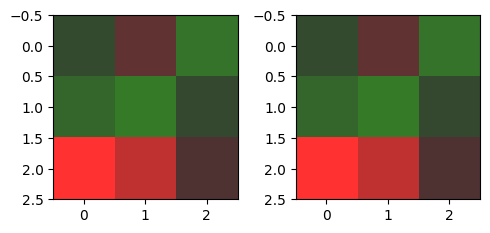

In [8]:
weights = list(Weight.objects.filter(coordinate__startswith=KERNEL_COORDINATE, data_type="weights").order_by("coordinate"))
_weights = [np.array(w.data) for w in weights]
kernel = np.stack(_weights)

S([kernel[0], _weights[0]])

In [9]:
from tqdm import tqdm

def get_pos(sm):
    res = []
    for r, row in enumerate(sm.data):
        for c, col in enumerate(row):
            if sm.data[r][c] > 0:
                res.append((col, (r, c), sm))
    return res

sms = list(SaliencyMap.objects.filter(coordinate=KERNEL_COORDINATE))
# print(len(sms))
pos_sms = []
for sm in tqdm(sms):
    val = sm.data[COORD[0]][COORD[1]] 
    if val > 0:
        pos_sms.append((val, KERNEL_COORDINATE, sm))

100%|██████████| 550/550 [00:00<00:00, 109939.82it/s]


In [10]:
d = SaliencyMap.objects.filter(coordinate=KERNEL_COORDINATE).first().data
out_h, out_w = len(d), len(d[0])
out_h, out_w

(7, 7)

Not good to get depressed, need to start again.  

In [11]:
val_and_patches = []
for alias, act in ip2act.items():
    sm = SaliencyMap.objects.filter(input__alias=alias, coordinate=KERNEL_COORDINATE).first()
    y, x = COORD
    if sm.data[y][x] > 0:
        (y0,x0), (y1,x1) = get_receptive(y,x)
        val_and_patches.append((sm.data[y][x], act[:, y0:y1, x0:x1]))

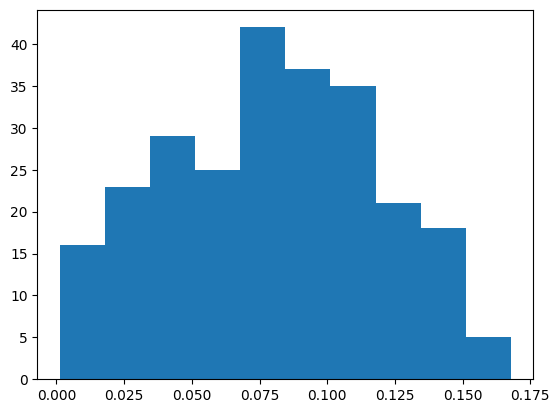

In [12]:
plt.hist([a[0] for a in val_and_patches])
plt.show()

In [ ]:
patches = [v[1] for v in val_and_patches if v[0] > 0.030]
len(val_and_patches), len(patches)

In [ ]:
def make_sparse(patch, num_std=1):
    mean, std = np.mean(patch), np.std(patch)
    thresh = mean + num_std * std

    sparse = patch.copy()
    sparse[np.abs(sparse) < thresh] = 0
    return sparse

In [ ]:
lin_patches = [p.reshape(-1) for p in patches]
pws = lin_patches * kernel.reshape(-1)
sparse_pws = [make_sparse(pw, 2) for pw in pws]

In [ ]:
X = do_pca(10, sparse_pws)

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import pandas as pd

results = []
K_range = range(2, 10) # Checking 2 to 10 clusters

for k in K_range:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X)
    
    # Calculate scores
    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    
    results.append({'k': k, 'silhouette': sil, 'calinski': ch})

# Convert to DataFrame to find the winner
df_results = pd.DataFrame(results)
best_k = df_results.loc[df_results['silhouette'].idxmax(), 'k']
print(f"The optimal number of clusters based on Silhouette is: {best_k}")

df_results

In [ ]:
from sklearn.cluster import HDBSCAN

dbscan = HDBSCAN(10)
dbscan.fit(X)
labels = dbscan.labels_
# model = AgglomerativeClustering(n_clusters=4, linkage='ward')
# labels = model.fit_predict(X)

In [ ]:
l2patch = defaultdict(list)
for i in range(len(labels)):
    l2patch[labels[i]].append(patches[i])

l2pw = defaultdict(list)
for i in range(len(labels)):
    l2pw[labels[i]].append(pws[i].reshape(8,3,3))

l2sparse = defaultdict(list)
for i in range(len(labels)):
    l2sparse[labels[i]].append(sparse_pws[i].reshape(8,3,3))

for l,v in l2patch.items():
    print(l, len(v))

In [ ]:
L = 0
for i in range(10):
    S([p for p in l2sparse[L][i]], 15, ncols=8, viztype="global")
    plt.show()

In [ ]:
L = 1
for i in range(10):
    S([p for p in l2sparse[L][i]], 15, ncols=8, viztype="global")
    plt.show()

In [ ]:
L = -1
for i in range(10):
    S([p for p in l2sparse[L][i]], 15, ncols=8, viztype="global")
    plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import pairwise_distances
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

def binarize_ternary(patches, threshold=0.0):
    """
    Convert thresholded patches to ternary support vectors.
    Values > 0  → +1 (strong positive activation)
    Values < 0  → -1 (strong negative activation)
    Values == 0 → 0  (already zeroed out by your thresholding step)
    """
    signs = np.zeros_like(patches, dtype=np.int8)
    signs[patches > threshold]  =  1
    signs[patches < -threshold] = -1
    return signs


def ternary_jaccard_distance(a, b):
    """
    Extended Jaccard for ternary (+1, 0, -1) support vectors.

    Intersection: positions where both are active AND agree in sign.
    Union:        positions where at least one is active (nonzero).

    This means:
      - +1 vs +1  → contributes to both intersection and union  (agree)
      - -1 vs -1  → contributes to both intersection and union  (agree)
      - +1 vs -1  → contributes to union only                   (conflict)
      -  0 vs ±1  → contributes to union only                   (absent in one)
      -  0 vs  0  → contributes to neither                      (both silent)
    """
    intersection = np.sum((a != 0) & (b != 0) & (a == b))
    union        = np.sum((a != 0) | (b != 0))
    if union == 0:
        return 0.0  # both fully zero — identical (distance = 0)
    return 1.0 - (intersection / union)


def compute_ternary_jaccard_matrix(ternary_patches):
    """
    Compute full pairwise ternary Jaccard distance matrix.
    Uses vectorised numpy ops — no Python-level loop over pairs.
    """
    n = len(ternary_patches)
    S = np.stack(ternary_patches)  # (n, d)

    pos = (S > 0).astype(np.float32)   # +1 support
    neg = (S < 0).astype(np.float32)   # -1 support

    # Intersection: same sign, both active
    # pos_i · pos_j  counts positions where both are +1
    # neg_i · neg_j  counts positions where both are -1
    intersection = pos @ pos.T + neg @ neg.T  # (n, n)

    # Union: at least one is active (regardless of sign)
    active = (S != 0).astype(np.float32)      # 1 where nonzero
    active_counts = active.sum(axis=1, keepdims=True)
    both_active = active @ active.T
    # |A ∪ B| = |A| + |B| - |A ∩ B|
    union = active_counts + active_counts.T - both_active

    # Avoid division by zero (both vectors fully zero)
    union = np.where(union == 0, 1, union)

    similarity = intersection / union
    distance   = 1.0 - similarity
    np.fill_diagonal(distance, 0.0)
    return distance


def cluster_patches(
    patches,
    n_clusters=None,
    distance_threshold=0.4,
    linkage="average"
):
    """
    Full pipeline:
      1. Binarize to ternary supports (+1 / 0 / -1)
      2. Compute pairwise ternary Jaccard distance matrix
      3. Agglomerative clustering with average linkage

    Args:
        patches:            list of numpy arrays, already thresholded
                            (non-relevant values set to 0)
        n_clusters:         if set, cut tree to exactly this many clusters
        distance_threshold: if n_clusters is None, cut tree at this distance
                            (0 = identical supports, 1 = fully disjoint)
        linkage:            "average" (default), "complete", or "single"
                            average = UPGMA, good balance for subspace structure

    Returns:
        labels:             numpy array of cluster assignments (length n)
        dist_matrix:        (n, n) pairwise distance matrix
        ternary:            (n, d) ternary support matrix
    """
    ternary    = binarize_ternary(patches)
    dist_matrix = compute_ternary_jaccard_matrix(ternary)

    clustering = AgglomerativeClustering(
        n_clusters=n_clusters,
        distance_threshold=distance_threshold if n_clusters is None else None,
        metric="precomputed",
        linkage=linkage,
    )
    labels = clustering.fit_predict(dist_matrix)

    return labels, dist_matrix, ternary


def cluster_summary(patches, labels, ternary):
    """
    Print a readable summary of each cluster:
      - size
      - dominant active positions (union of supports)
      - sign breakdown: what fraction are purely positive / negative / mixed
    """
    n_clusters = labels.max() + 1
    for c in range(n_clusters):
        idx  = np.where(labels == c)[0]
        subs = ternary[idx]             # (cluster_size, d)

        active_positions  = np.where(np.any(subs != 0, axis=0))[0]
        pos_only = np.sum(np.all(subs >= 0, axis=0) & np.any(subs > 0, axis=0))
        neg_only = np.sum(np.all(subs <= 0, axis=0) & np.any(subs < 0, axis=0))
        mixed    = len(active_positions) - pos_only - neg_only

        print(
            f"Cluster {c:2d} | "
            f"n={len(idx):4d} | "
            f"active dims={len(active_positions):4d} | "
            f"pos-only={pos_only} neg-only={neg_only} mixed={mixed}"
        )

In [ ]:
labels, dist_matrix, ternary =cluster_patches(pws )

In [ ]:
np.unique(labels, return_counts=True)

In [ ]:
l2patch = defaultdict(list)
for i in range(len(labels)):
    l2patch[labels[i]].append(patches[i])

l2pw = defaultdict(list)
for i in range(len(labels)):
    l2pw[labels[i]].append(pws[i].reshape(8,3,3))

l2sparse = defaultdict(list)
for i in range(len(labels)):
    l2sparse[labels[i]].append(sparse_pws[i].reshape(8,3,3))

for l,v in l2patch.items():
    print(l, len(v))

In [ ]:
L = 14
for i in range(10):
    if i >= len(l2sparse[L]):
        break
    S([p for p in l2sparse[L][i]], 15, ncols=8, viztype="global")
    plt.show()